# Workshop 5: Population Statistics Pipeline (NSO)

EDA ข้อมูลประชากรจาก NSO Open Data สำหรับฝึก workflow วิเคราะห์ข้อมูลภาครัฐ

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/toche7/SlideAIDATADGA/blob/main/slides/workshop-05-population-statistics-pipeline.ipynb)

## Learning Objectives
- ดึงข้อมูลจาก NSO API มาเก็บใน DataFrame
- ตรวจสอบ data quality และเตรียมข้อมูลให้พร้อมวิเคราะห์
- ทำ EDA เพื่อหาแนวโน้มประชากรตามจังหวัด เพศ และช่วงอายุ
- สรุป Insight ที่สื่อสารได้กับทีมงานหรือผู้บริหาร

In [1]:
# 1) Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

In [2]:
# 2) Load data from NSO API (fallback included)
api_url = (
    'https://catalog.nso.go.th/api/3/action/datastore_search'
    '?resource_id=57ff7cd9-27e3-4dc5-b6ad-e8280ab18a05&limit=5000'
)
fallback_url = 'https://raw.githubusercontent.com/toche7/DataSets/refs/heads/main/nso_population.csv'

try:
    api_json = pd.read_json(api_url)
    records = api_json.loc['records', 'result']
    df = pd.DataFrame(records)
    source = 'NSO API'
except Exception:
    df = pd.read_csv(fallback_url)
    source = 'Fallback CSV'

print('Loaded from:', source)
print('Shape:', df.shape)
df.head()

Loaded from: Fallback CSV
Shape: (5000, 10)


,_id,year,region,province,area,sex,age_group,value,unit,source
0,1,2533,ทั่วประเทศ,รวม,รวม,รวม,รวม,54548530,คน,สำนักงานสถิติแห่งชาติ
1,2,2533,ทั่วประเทศ,รวม,รวม,ชาย,รวม,27061733,คน,สำนักงานสถิติแห่งชาติ
2,3,2533,ทั่วประเทศ,รวม,รวม,หญิง,รวม,27486797,คน,สำนักงานสถิติแห่งชาติ
3,4,2533,ทั่วประเทศ,รวม,ในเขตเทศบาล,รวม,รวม,10215098,คน,สำนักงานสถิติแห่งชาติ
4,5,2533,ทั่วประเทศ,รวม,ในเขตเทศบาล,ชาย,รวม,4933482,คน,สำนักงานสถิติแห่งชาติ


In [3]:
# 3) Quick data profile
display(df.info())
display(df.describe(include='all').T.head(15))

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
display(pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).head(15))
print('Duplicate rows:', int(df.duplicated().sum()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   _id        5000 non-null   int64 
 1   year       5000 non-null   int64 
 2   region     5000 non-null   object
 3   province   5000 non-null   object
 4   area       5000 non-null   object
 5   sex        5000 non-null   object
 6   age_group  5000 non-null   object
 7   value      5000 non-null   int64 
 8   unit       5000 non-null   object
 9   source     5000 non-null   object
dtypes: int64(3), object(7)
memory usage: 390.8+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
_id,5000.0,NaN,NaN,NaN,2500.5,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
year,5000.0,NaN,NaN,NaN,2543.002,8.167823,2533.0,2533.0,2543.0,2553.0,2553.0
region,5000,3,ภาคกลาง,4187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province,5000,10,รวม,972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,5000,3,รวม,1721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,5000,3,รวม,1667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_group,5000,18,รวม,288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value,5000.0,NaN,NaN,NaN,415844.4764,2426742.822436,0.0,5947.0,17696.5,113869.75,65981659.0
unit,5000,1,คน,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,5000,1,สำนักงานสถิติแห่งชาติ,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_count,missing_pct
_id,0,0.0
year,0,0.0
region,0,0.0
province,0,0.0
area,0,0.0
sex,0,0.0
age_group,0,0.0
value,0,0.0
unit,0,0.0
source,0,0.0


Duplicate rows: 0


In [4]:
# 4) Data preparation
df_clean = df.copy()

# Type conversion
for col in ['year', 'value']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

text_cols = [c for c in ['region', 'province', 'area', 'sex', 'age_group'] if c in df_clean.columns]
for c in text_cols:
    df_clean[c] = df_clean[c].astype('string').str.strip()

# Remove exact duplicates and rows without key fields
df_clean = df_clean.drop_duplicates()
required_cols = [c for c in ['year', 'province', 'sex', 'age_group', 'value'] if c in df_clean.columns]
df_clean = df_clean.dropna(subset=required_cols)

print('Original shape:', df.shape)
print('Cleaned shape :', df_clean.shape)
print('Remaining missing:', int(df_clean.isna().sum().sum()))

Original shape: (5000, 10)
Cleaned shape : (5000, 10)
Remaining missing: 0


In [5]:
# 5) Outlier check on value using IQR
q1 = df_clean['value'].quantile(0.25)
q3 = df_clean['value'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df_clean[(df_clean['value'] < lower) | (df_clean['value'] > upper)]
print('Outlier rows:', len(outliers))
display(outliers.head())

Outlier rows: 938


,_id,year,region,province,area,sex,age_group,value,unit,source
0,1,2533,ทั่วประเทศ,รวม,รวม,รวม,รวม,54548530,คน,สำนักงานสถิติแห่งชาติ
1,2,2533,ทั่วประเทศ,รวม,รวม,ชาย,รวม,27061733,คน,สำนักงานสถิติแห่งชาติ
2,3,2533,ทั่วประเทศ,รวม,รวม,หญิง,รวม,27486797,คน,สำนักงานสถิติแห่งชาติ
3,4,2533,ทั่วประเทศ,รวม,ในเขตเทศบาล,รวม,รวม,10215098,คน,สำนักงานสถิติแห่งชาติ
4,5,2533,ทั่วประเทศ,รวม,ในเขตเทศบาล,ชาย,รวม,4933482,คน,สำนักงานสถิติแห่งชาติ


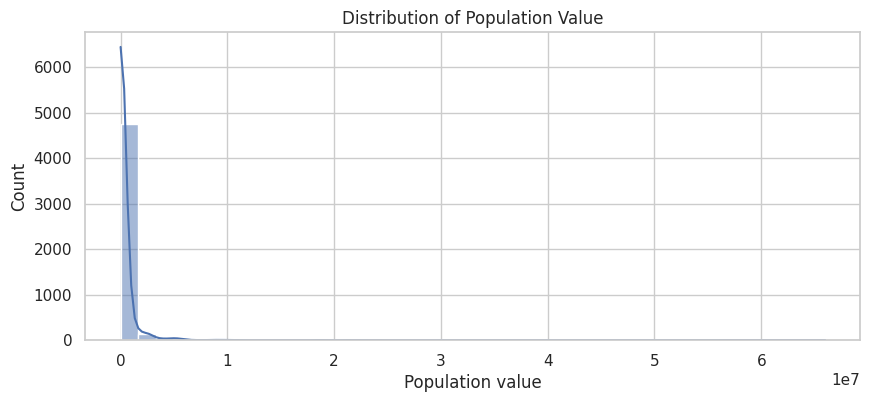

In [6]:
# 6) EDA: distribution of population value
plt.figure(figsize=(10, 4))
sns.histplot(df_clean['value'], bins=40, kde=True)
plt.title('Distribution of Population Value')
plt.xlabel('Population value')
plt.ylabel('Count')
plt.show()

,province,value
0,กรุงเทพมหานคร,164342180
4,ชลบุรี,27579229
1,กาญจนบุรี,17415628
8,นครปฐม,17338929
3,ฉะเชิงเทรา,15637914
2,จันทบุรี,10850584
5,ชัยนาท,8180365
7,นครนายก,5464662
6,ตราด,5035576


/tmp/ipykernel_9354/3641182684.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_province, y='province', x='value', palette='Greens_r')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3591 (\N{T

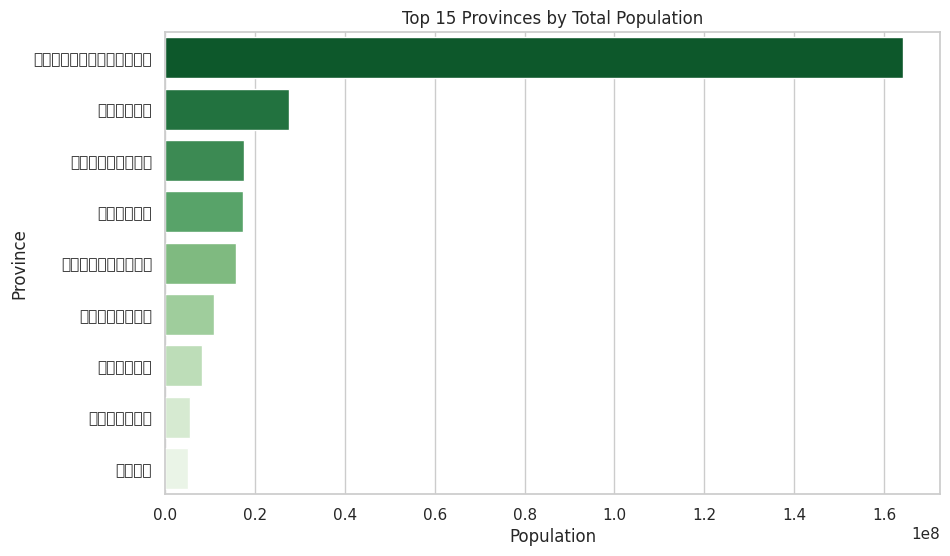

In [7]:
# 7) EDA: top provinces by total population
province_df = df_clean[df_clean['province'] != 'รวม'].copy()

top_province = (
    province_df.groupby('province', as_index=False)['value']
    .sum()
    .sort_values('value', ascending=False)
    .head(15)
)
display(top_province)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_province, y='province', x='value', palette='Greens_r')
plt.title('Top 15 Provinces by Total Population')
plt.xlabel('Population')
plt.ylabel('Province')
plt.show()

,year,sex,value
0,2533,ชาย,150689913
1,2533,หญิง,154374078
2,2543,ชาย,168733614
3,2543,หญิง,175042478
4,2553,ชาย,191567578


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3597 (\N{THAI CHARACTER YO YING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, *

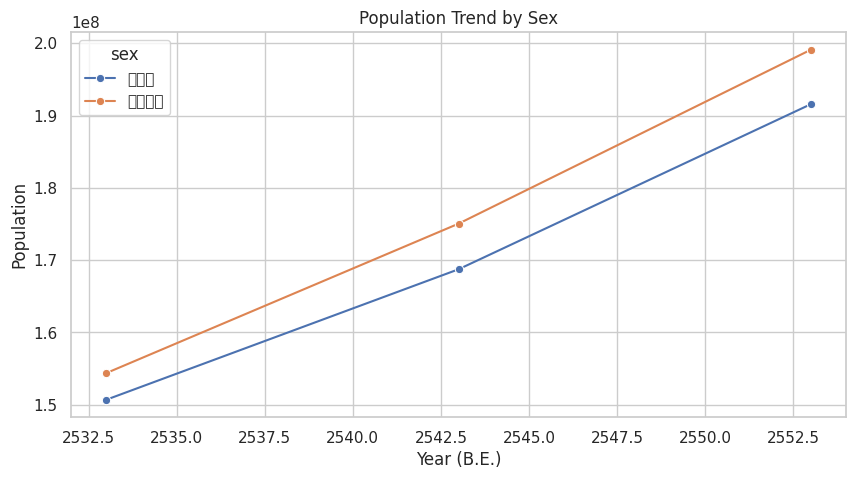

In [8]:
# 8) EDA: sex distribution by year
sex_year = (
    df_clean[df_clean['sex'].isin(['ชาย', 'หญิง'])]
    .groupby(['year', 'sex'], as_index=False)['value']
    .sum()
)
display(sex_year.head())

plt.figure(figsize=(10, 5))
sns.lineplot(data=sex_year, x='year', y='value', hue='sex', marker='o')
plt.title('Population Trend by Sex')
plt.xlabel('Year (B.E.)')
plt.ylabel('Population')
plt.show()

In [9]:
# 9) Build tidy summary for reporting
summary = (
    df_clean[df_clean['province'] != 'รวม']
    .groupby(['year', 'region', 'sex'], as_index=False)['value']
    .sum()
    .rename(columns={'value': 'population_total'})
)

display(summary.head())
print('Summary shape:', summary.shape)

,year,region,sex,population_total
0,2533,กรุงเทพมหานคร,ชาย,11326408
1,2533,กรุงเทพมหานคร,รวม,23529644
2,2533,กรุงเทพมหานคร,หญิง,12203236
3,2533,ภาคกลาง,ชาย,7427697
4,2533,ภาคกลาง,รวม,15462401


Summary shape: (18, 4)


In [10]:
# 10) Export outputs
df_clean.to_csv('workshop5_nso_population_clean.csv', index=False)
summary.to_csv('workshop5_nso_population_summary.csv', index=False)
print('Saved: workshop5_nso_population_clean.csv')
print('Saved: workshop5_nso_population_summary.csv')

Saved: workshop5_nso_population_clean.csv
Saved: workshop5_nso_population_summary.csv


## Reflection Questions
1. จังหวัดใดมีประชากรรวมสูงสุด และมีแนวโน้มเปลี่ยนแปลงอย่างไร?
2. โครงสร้างเพศในแต่ละปีมี pattern อย่างไร?
3. มีความเสี่ยงด้านคุณภาพข้อมูลข้อใดที่อาจกระทบการตีความ?
4. สรุป Insight สำคัญ 3 ข้อในรูปแบบ bullet